In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv


/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv
   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  

Shape: (6335, 4)

Columns:
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

Missing Values:
Unnamed: 0    0
title         0
text          0
labe

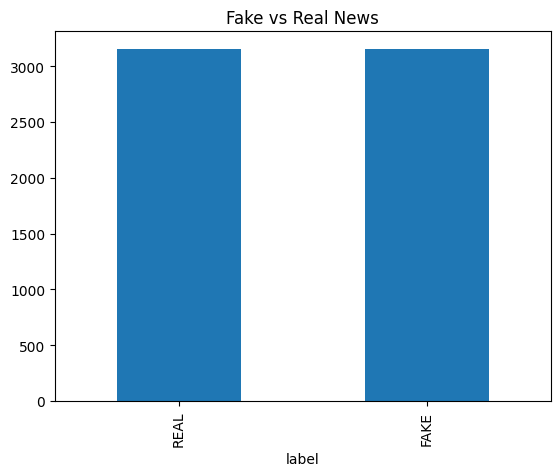

label
REAL    3154
FAKE    3152
Name: count, dtype: int64

LOGISTIC REGRESSION
Accuracy: 0.9072900158478605
              precision    recall  f1-score   support

        FAKE       0.90      0.92      0.91       631
        REAL       0.92      0.89      0.91       631

    accuracy                           0.91      1262
   macro avg       0.91      0.91      0.91      1262
weighted avg       0.91      0.91      0.91      1262

[[581  50]
 [ 67 564]]

LINEAR SVM
Accuracy: 0.9096671949286846
              precision    recall  f1-score   support

        FAKE       0.92      0.90      0.91       631
        REAL       0.90      0.92      0.91       631

    accuracy                           0.91      1262
   macro avg       0.91      0.91      0.91      1262
weighted avg       0.91      0.91      0.91      1262

[[569  62]
 [ 52 579]]

 Logistic Regression
Accuracy: 0.9072900158478605
Precision: 0.8966049382716049
Recall: 0.9207606973058637
F1: 0.90852228303362

 Linear SVM
Accuracy:

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)





for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv(
    "/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv"
)





print(df.head())

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())



df = df.drop(columns=["Unnamed: 0"], errors="ignore")



df = df.drop_duplicates()
df = df.dropna()




df["label"].value_counts().plot(
    kind="bar",
    title="Fake vs Real News"
)

plt.show()

print(df["label"].value_counts())




X = (
    df["title"].fillna("")
    + " "
    + df["text"].fillna("")
)

X = X.str.lower()

y = df["label"]





X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)





tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train = tfidf.fit_transform(X_train_text)

X_test = tfidf.transform(X_test_text)




model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

lr_pred = model.predict(X_test)

print("\nLOGISTIC REGRESSION")

print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

print(
    confusion_matrix(
        y_test,
        lr_pred
    )
)






svm = LinearSVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("\nLINEAR SVM")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        svm_pred
    )
)

print(
    classification_report(
        y_test,
        svm_pred
    )
)

print(
    confusion_matrix(
        y_test,
        svm_pred
    )
)




models = {
    "Logistic Regression": model,
    "Linear SVM": svm
}

for name, clf in models.items():

    pred = clf.predict(X_test)

    print("\n", name)

    print(
        "Accuracy:",
        accuracy_score(
            y_test,
            pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_test,
            pred,
            pos_label="FAKE"
        )
    )

    print(
        "Recall:",
        recall_score(
            y_test,
            pred,
            pos_label="FAKE"
        )
    )

    print(
        "F1:",
        f1_score(
            y_test,
            pred,
            pos_label="FAKE"
        )
    )




news = [
"""
India launches a new satellite mission successfully from Sriharikota.
Scientists say the mission will improve communication capabilities.
"""
]

news_vector = tfidf.transform(news)

print("\nCustom Prediction")

print(
    "Logistic:",
    model.predict(news_vector)[0]
)

print(
    "Probabilities:"
)

probs = model.predict_proba(news_vector)

for label, prob in zip(
    model.classes_,
    probs[0]
):
    print(label, ":", round(prob,4))

print(
    "SVM:",
    svm.predict(news_vector)[0]
)





for i in range(10):

    text = X_test_text.iloc[i]

    actual = y_test.iloc[i]

    pred = svm.predict(
        tfidf.transform([text])
    )[0]

    print("\nArticle", i+1)

    print("Actual:", actual)

    print("Predicted:", pred)
    correct = 0

for i in range(len(X_test_text)):

    text = X_test_text.iloc[i]

    actual = y_test.iloc[i]

    pred = svm.predict(
        tfidf.transform([text])
    )[0]

    if pred == actual:
        correct += 1

print("Correct Predictions:", correct)

print("Total Articles:", len(X_test_text))

print(
    "Accuracy:",
    correct / len(X_test_text)
)





joblib.dump(
    model,
    "fake_news_model.pkl"
)

joblib.dump(
    svm,
    "svm_fake_news.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("\nFiles Saved:")
print(os.listdir())